# Comparacion de ultimas actividades

Compara la actividad mas reciente de los ciclistas marcados con `carrera = 1` en `data/burgos.csv`.

Antes de ejecutar, define la variable de entorno `INTERVALS_API_KEY`. La clave no se guarda en este cuaderno.

In [13]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from requests.auth import HTTPBasicAuth

RUTA_BURGOS = Path('data/burgos.csv')
API_KEY = "1347lyp9p4meza7lyd3sar4qu"
if not API_KEY:
    raise RuntimeError('Falta la variable de entorno INTERVALS_API_KEY.')

if not RUTA_BURGOS.exists():
    raise FileNotFoundError(f'No existe {RUTA_BURGOS.resolve()}')

auth = HTTPBasicAuth('API_KEY', API_KEY)
SESION = requests.Session()
SESION.auth = auth
SESION.headers.update({'Accept': 'application/json'})
TIMEOUT = 30

burgos = pd.read_csv(RUTA_BURGOS, sep=';')
burgos['intervals_id'] = burgos['intervals_id'].astype(str)
burgos['carrera'] = pd.to_numeric(burgos['carrera'], errors='coerce').fillna(0).astype(int)
burgos['weight'] = pd.to_numeric(burgos['weight'], errors='coerce')
ciclistas = burgos[burgos['carrera'].eq(1)].copy()
if ciclistas.empty:
    raise ValueError('No hay ciclistas con carrera = 1 en data/burgos.csv.')

ciclistas[['Name', 'intervals_id', 'weight']]

,Name,intervals_id,weight
2,Sinuhe Fernandez,i545516,60
5,Jose Luis Faura,i547904,67
6,Jose Manuel Diaz,i547157,64
10,Cesar Macias,i281806,57
12,Mario Aparicio,i554068,71


In [14]:
def primer_valor(datos, nombres, default=None):
    for nombre in nombres:
        valor = datos.get(nombre)
        if valor is not None and valor != '':
            return valor
    return default


def solicitar_json(url, params=None):
    try:
        respuesta = SESION.get(url, params=params, timeout=TIMEOUT)
        respuesta.raise_for_status()
        return respuesta.json(), None
    except requests.RequestException as error:
        return None, f'{type(error).__name__}: {error}'
    except ValueError as error:
        return None, f'Respuesta JSON no valida: {error}'


def convertir_numero(valor):
    return pd.to_numeric(valor, errors='coerce')


def descargar_ultima_actividad(athlete_id):
    url = f'https://intervals.icu/api/v1/athlete/{athlete_id}/activities'
    datos, error = solicitar_json(url, params={'oldest': '2000-01-01', 'newest': '2100-01-01'})
    if error or not isinstance(datos, list):
        return None, error or 'La API no devolvio una lista de actividades.'
    actividades = [actividad for actividad in datos if isinstance(actividad, dict)]
    if not actividades:
        return None, 'No hay actividades.'
    actividades.sort(key=lambda actividad: str(primer_valor(actividad, ['start_date_local', 'start_date', 'date'], '')), reverse=True)
    return actividades[0], None


def obtener_detalle_actividad(actividad):
    actividad_id = primer_valor(actividad, ['id', 'activity_id'])
    if not actividad_id:
        return {}, 'La actividad no tiene id.'
    url = f'https://intervals.icu/api/v1/activity/{actividad_id}'
    detalle, error = solicitar_json(url)
    if error:
        return actividad, error
    if isinstance(detalle, list):
        detalle = detalle[0] if detalle else {}
    if not isinstance(detalle, dict):
        return actividad, 'El detalle no tiene formato de objeto.'
    combinado = actividad.copy()
    combinado.update(detalle)
    return combinado, None


def construir_registro(nombre, peso, actividad, error=None):
    fecha = primer_valor(actividad, ['start_date_local', 'start_date', 'date'])
    fecha = str(fecha)[:19] if fecha is not None else pd.NA
    duracion = convertir_numero(primer_valor(actividad, ['moving_time', 'elapsed_time', 'duration']))
    distancia = convertir_numero(primer_valor(actividad, ['distance', 'distance_m']))
    desnivel = convertir_numero(primer_valor(actividad, ['elevation_gain', 'total_elevation_gain', 'elev_gain']))
    potencia_media = convertir_numero(primer_valor(actividad, ['avg_watts', 'average_watts', 'power']))
    potencia_normalizada = convertir_numero(primer_valor(actividad, ['weighted_avg_watts', 'normalized_power', 'np']))
    tss = convertir_numero(primer_valor(actividad, ['tss', 'icu_training_load', 'training_load']))
    kj = convertir_numero(primer_valor(actividad, ['kilojoules', 'total_work_kj', 'work_kj']))
    kj_kg = kj / peso if pd.notna(kj) and pd.notna(peso) and peso > 0 else pd.NA
    return {
        'Ciclista': nombre,
        'Peso (kg)': peso,
        'Fecha': fecha,
        'Actividad': primer_valor(actividad, ['name', 'title'], pd.NA),
        'Tipo': primer_valor(actividad, ['type', 'sport'], pd.NA),
        'Distancia (km)': distancia / 1000 if pd.notna(distancia) and distancia > 100 else distancia,
        'Duracion (min)': duracion / 60 if pd.notna(duracion) else pd.NA,
        'Desnivel (m)': desnivel,
        'Potencia media (W)': potencia_media,
        'Potencia normalizada (W)': potencia_normalizada,
        'TSS': tss,
        'Energia (kJ)': kj,
        'Energia (kJ/kg)': kj_kg,
        'Estado': error or 'OK',
    }

In [15]:
registros = []
for _, ciclista in ciclistas.iterrows():
    nombre = ciclista['Name']
    peso = ciclista['weight']
    actividad, error = descargar_ultima_actividad(ciclista['intervals_id'])
    if actividad is None:
        registros.append(construir_registro(nombre, peso, {}, error))
        continue
    detalle, error_detalle = obtener_detalle_actividad(actividad)
    registros.append(construir_registro(nombre, peso, detalle, error_detalle))

comparacion = pd.DataFrame(registros)
columnas_numericas = [
    'Peso (kg)', 'Distancia (km)', 'Duracion (min)', 'Desnivel (m)',
    'Potencia media (W)', 'Potencia normalizada (W)', 'TSS',
    'Energia (kJ)', 'Energia (kJ/kg)'
]
comparacion[columnas_numericas] = comparacion[columnas_numericas].apply(pd.to_numeric, errors='coerce')
faltantes = comparacion.isna().sum().rename('Campos sin dato').to_frame()

print('Actividades comparadas:', len(comparacion))
display(comparacion.style.format({columna: '{:.1f}' for columna in columnas_numericas}, na_rep='N/D'))

Actividades comparadas: 5


,Ciclista,Peso (kg),Fecha,Actividad,Tipo,Distancia (km),Duracion (min),Desnivel (m),Potencia media (W),Potencia normalizada (W),TSS,Energia (kJ),Energia (kJ/kg),Estado
0,Sinuhe Fernandez,60.0,2026-08-23T11:39:58,Monaco Ciclismo en ruta,Ride,224.0,348.0,3165.0,N/D,N/D,306.0,N/D,N/D,OK
1,Jose Luis Faura,67.0,2026-08-23T11:39:48,Ciclismo,Ride,224.8,344.2,3744.0,N/D,N/D,223.0,N/D,N/D,OK
2,Jose Manuel Diaz,64.0,2026-08-23T11:42:07,N/D,N/D,N/D,N/D,N/D,N/D,N/D,N/D,N/D,N/D,OK
3,Cesar Macias,57.0,2026-08-23T11:53:04,Monaco Ciclismo en ruta,Ride,222.6,337.2,3171.0,N/D,N/D,256.0,N/D,N/D,OK
4,Mario Aparicio,71.0,2026-08-23T11:41:47,Lunch Ciclismo,Ride,224.7,343.1,3321.0,N/D,N/D,240.0,N/D,N/D,OK


Resumen de campos ausentes:


,Campos sin dato
Actividad,1
Tipo,1
Distancia (km),1
Duracion (min),1
Desnivel (m),1
Potencia media (W),5
Potencia normalizada (W),5
TSS,1
Energia (kJ),5
Energia (kJ/kg),5


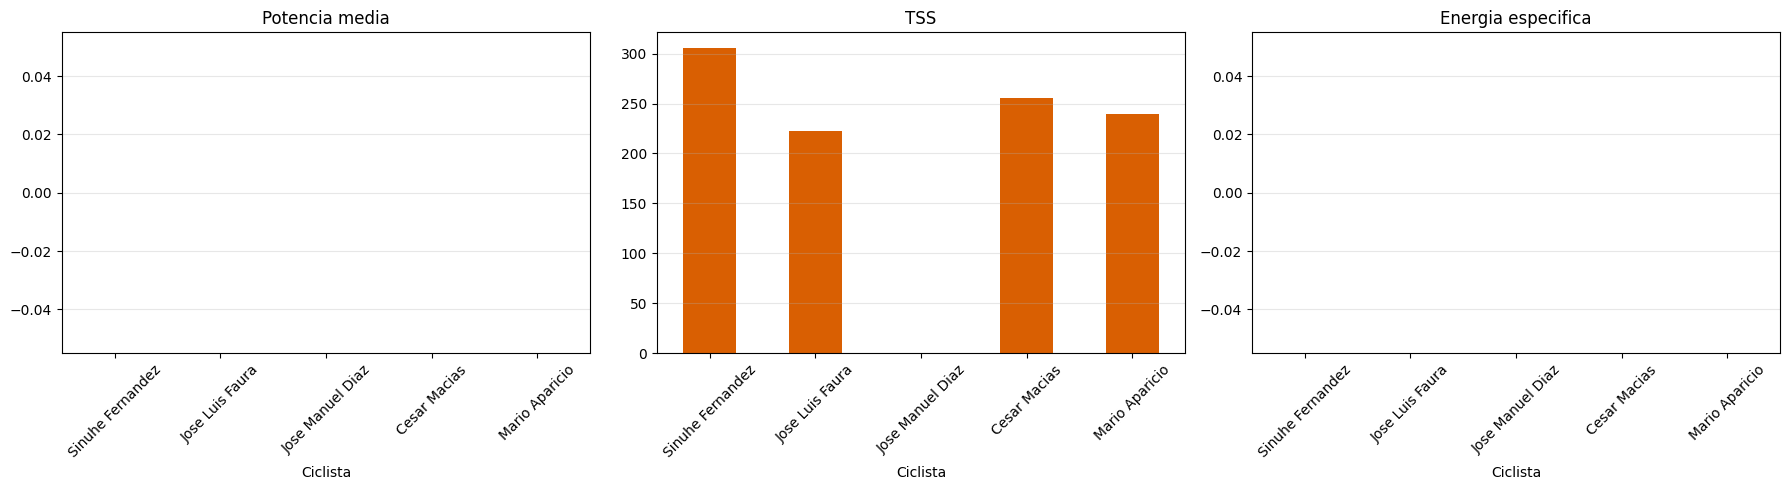

In [16]:
print('Resumen de campos ausentes:')
display(faltantes[faltantes['Campos sin dato'] > 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
comparacion.plot.bar(x='Ciclista', y='Potencia media (W)', ax=axes[0], legend=False, color='#2878b5')
comparacion.plot.bar(x='Ciclista', y='TSS', ax=axes[1], legend=False, color='#d95f02')
comparacion.plot.bar(x='Ciclista', y='Energia (kJ/kg)', ax=axes[2], legend=False, color='#1b9e77')
axes[0].set_title('Potencia media')
axes[1].set_title('TSS')
axes[2].set_title('Energia especifica')
for eje in axes:
    eje.tick_params(axis='x', rotation=45)
    eje.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Informe PDF

La siguiente celda genera un informe similar al de etapas: portada comparativa y una ficha individual por ciclista.

In [17]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

RUTA_INFORME = Path('informe_ultimas_actividades.pdf')


def texto(valor, formato=None):
    if pd.isna(valor):
        return 'N/D'
    return formato.format(valor) if formato else str(valor)


def dibujar_cabecera(ax, titulo, subtitulo=''):
    ax.axis('off')
    ax.text(0.02, 0.72, titulo, fontsize=22, fontweight='bold', color='#17324d')
    if subtitulo:
        ax.text(0.02, 0.30, subtitulo, fontsize=11, color='#5f6f7a')


def dibujar_tarjetas(ax, fila):
    ax.axis('off')
    metricas = [
        ('TSS', texto(fila['TSS'], '{:.0f}')),
        ('Potencia media', texto(fila['Potencia media (W)'], '{:.0f}') + ' W'),
        ('Energia', texto(fila['Energia (kJ)'], '{:.0f}') + ' kJ'),
        ('Energia / kg', texto(fila['Energia (kJ/kg)'], '{:.2f}') + ' kJ/kg'),
    ]
    for indice, (etiqueta, valor) in enumerate(metricas):
        izquierda = 0.02 + indice * 0.245
        ax.text(izquierda, 0.62, etiqueta, fontsize=10, color='#5f6f7a')
        ax.text(izquierda, 0.22, valor, fontsize=18, fontweight='bold', color='#17324d')


with PdfPages(RUTA_INFORME) as pdf:
    fig = plt.figure(figsize=(16, 14), constrained_layout=True)
    grid = fig.add_gridspec(5, 1, height_ratios=[0.8, 0.9, 3.2, 3.2, 3.2])
    cabecera = fig.add_subplot(grid[0])
    dibujar_cabecera(cabecera, 'Informe de ultimas actividades', f'{len(comparacion)} ciclistas | generado {pd.Timestamp.now():%Y-%m-%d %H:%M}')
    resumen = fig.add_subplot(grid[1])
    resumen.axis('off')
    resumen.text(0.02, 0.68, 'Resumen de la actividad mas reciente', fontsize=13, fontweight='bold', color='#17324d')
    resumen.text(0.02, 0.20, 'Los campos no disponibles se muestran como N/D.', fontsize=10, color='#5f6f7a')

    for posicion, (columna, color, titulo) in enumerate([
        ('Potencia media (W)', '#2878b5', 'Potencia media'),
        ('TSS', '#d95f02', 'TSS'),
        ('Energia (kJ/kg)', '#1b9e77', 'Energia especifica'),
    ]):
        ax = fig.add_subplot(grid[2 + posicion])
        datos = comparacion.dropna(subset=[columna])
        if datos.empty:
            ax.text(0.5, 0.5, f'Sin datos de {titulo}', ha='center', va='center')
            ax.axis('off')
            continue
        ax.bar(datos['Ciclista'], datos[columna], color=color)
        ax.set_title(titulo, loc='left', fontweight='bold')
        ax.grid(axis='y', alpha=0.25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=False))
        ax.tick_params(axis='x', rotation=35)
        ax.set_ylabel(columna.split(' (')[0])
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    for _, fila in comparacion.iterrows():
        fig = plt.figure(figsize=(16, 10), constrained_layout=True)
        grid = fig.add_gridspec(5, 1, height_ratios=[0.9, 0.8, 1.4, 3.5, 0.4])
        cabecera = fig.add_subplot(grid[0])
        subtitulo = f"{texto(fila['Fecha'])} | {texto(fila['Tipo'])} | estado: {texto(fila['Estado'])}"
        dibujar_cabecera(cabecera, texto(fila['Ciclista']), subtitulo)

        tarjetas = fig.add_subplot(grid[1])
        dibujar_tarjetas(tarjetas, fila)

        perfil = fig.add_subplot(grid[2])
        perfil.axis('off')
        perfil.text(0.02, 0.82, 'Perfil de la actividad', fontsize=13, fontweight='bold', color='#17324d')
        perfil.text(0.02, 0.30, f"Actividad: {texto(fila['Actividad'])}", fontsize=11)
        perfil.text(0.38, 0.30, f"Distancia: {texto(fila['Distancia (km)'], '{:.1f}')} km", fontsize=11)
        perfil.text(0.62, 0.30, f"Duracion: {texto(fila['Duracion (min)'], '{:.0f}')} min", fontsize=11)
        perfil.text(0.82, 0.30, f"Desnivel: {texto(fila['Desnivel (m)'], '{:.0f}')} m", fontsize=11)

        grafico = fig.add_subplot(grid[3])
        metricas = ['Potencia media (W)', 'Potencia normalizada (W)', 'TSS', 'Energia (kJ/kg)']
        valores = [fila[metrica] for metrica in metricas]
        colores = ['#2878b5', '#6a3d9a', '#d95f02', '#1b9e77']
        validos = [(metrica, valor, color) for metrica, valor, color in zip(metricas, valores, colores) if pd.notna(valor)]
        if validos:
            grafico.bar([item[0].replace(' (W)', '').replace(' (kJ/kg)', '') for item in validos], [item[1] for item in validos], color=[item[2] for item in validos])
            grafico.set_title('Metricas de la actividad', loc='left', fontweight='bold')
            grafico.grid(axis='y', alpha=0.25)
            grafico.tick_params(axis='x', rotation=20)
        else:
            grafico.text(0.5, 0.5, 'No hay metricas numericas disponibles', ha='center', va='center')
            grafico.axis('off')

        pie = fig.add_subplot(grid[4])
        pie.axis('off')
        pie.text(0.02, 0.2, 'Fuente: Intervals.icu | Peso de data/burgos.csv', fontsize=9, color='#5f6f7a')
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f'Informe generado en: {RUTA_INFORME.resolve()}')
RUTA_INFORME

Informe generado en: C:\Users\echav\OneDrive\Documentos\GitHub\procyclingstats\informe_ultimas_actividades.pdf


WindowsPath('informe_ultimas_actividades.pdf')